# EDA - Melting Point Prediction

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

In [3]:
train_path = 'datasets/train.csv'
test_path = 'datasets/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
train_df.head()

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Basic shape and schema

In [4]:
print('train:', train_df.shape)
print('test:', test_df.shape)

display(train_df.dtypes.head(10))
display(train_df.dtypes.tail(10))

train: (2662, 427)
test: (666, 426)


id           int64
SMILES      object
Tm         float64
Group 1      int64
Group 2      int64
Group 3      int64
Group 4      int64
Group 5      int64
Group 6      int64
Group 7      int64
dtype: object

Group 415    int64
Group 416    int64
Group 417    int64
Group 418    int64
Group 419    int64
Group 420    int64
Group 421    int64
Group 422    int64
Group 423    int64
Group 424    int64
dtype: object

In [5]:
missing = train_df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

Series([], dtype: int64)

In [6]:
duplicate_rows = train_df.duplicated().sum()
print('duplicate rows:', duplicate_rows)

duplicate rows: 0


## Target overview

In [7]:
target_col = 'Tm'
train_df[target_col].describe()

count    2662.000000
mean      278.263452
std        85.117914
min        53.540000
25%       217.000000
50%       277.300000
75%       325.150000
max       897.150000
Name: Tm, dtype: float64

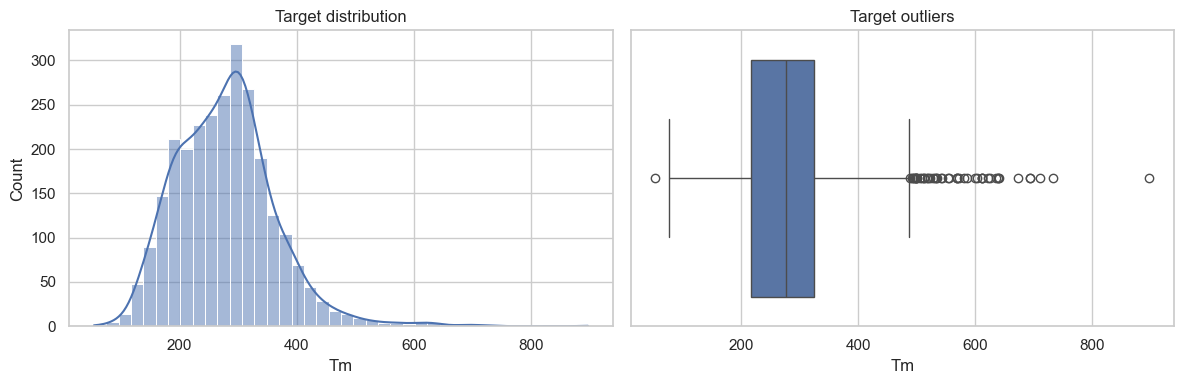

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df[target_col], bins=40, ax=axes[0], kde=True)
axes[0].set_title('Target distribution')
sns.boxplot(x=train_df[target_col], ax=axes[1])
axes[1].set_title('Target outliers')
plt.tight_layout()

## Feature summary

In [9]:
feature_cols = [c for c in train_df.columns if c != target_col]
train_df[feature_cols].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
id,2662.0,1652.887303,955.005512,1.0,830.25,1642.5,2469.75,3328.0
Group 1,2662.0,1.020661,1.353640,0.0,0.00,1.0,2.00,16.0
Group 2,2662.0,1.582269,3.738416,0.0,0.00,0.0,1.00,42.0
Group 3,2662.0,0.114951,0.425964,0.0,0.00,0.0,0.00,6.0
Group 4,2662.0,0.036439,0.208307,0.0,0.00,0.0,0.00,3.0
Group 5,2662.0,0.036814,0.205516,0.0,0.00,0.0,0.00,2.0
Group 6,2662.0,0.022915,0.164037,0.0,0.00,0.0,0.00,2.0
Group 7,2662.0,0.013524,0.118732,0.0,0.00,0.0,0.00,2.0
Group 8,2662.0,0.010143,0.117480,0.0,0.00,0.0,0.00,2.0
Group 9,2662.0,0.007137,0.092695,0.0,0.00,0.0,0.00,2.0


In [10]:
nunique = train_df[feature_cols].nunique().sort_values()
constant_cols = nunique[nunique <= 1]
low_variance_cols = nunique[(nunique > 1) & (nunique <= 3)]
print('constant cols:', constant_cols.index.tolist())
print('low variance cols (<=3 unique):', low_variance_cols.index.tolist())

constant cols: ['Group 424', 'Group 282', 'Group 285', 'Group 294', 'Group 303', 'Group 104', 'Group 102', 'Group 101', 'Group 306', 'Group 307', 'Group 308', 'Group 309', 'Group 312', 'Group 90', 'Group 88', 'Group 316', 'Group 317', 'Group 85', 'Group 84', 'Group 75', 'Group 74', 'Group 73', 'Group 67', 'Group 340', 'Group 342', 'Group 345', 'Group 281', 'Group 280', 'Group 264', 'Group 253', 'Group 183', 'Group 194', 'Group 198', 'Group 206', 'Group 207', 'Group 208', 'Group 167', 'Group 209', 'Group 423', 'Group 212', 'Group 213', 'Group 214', 'Group 347', 'Group 160', 'Group 158', 'Group 216', 'Group 217', 'Group 155', 'Group 218', 'Group 152', 'Group 150', 'Group 245', 'Group 247', 'Group 248', 'Group 250', 'Group 252', 'Group 215', 'Group 348', 'Group 313', 'Group 350', 'Group 377', 'Group 376', 'Group 371', 'Group 397', 'Group 399', 'Group 12', 'Group 363', 'Group 360', 'Group 46', 'Group 411', 'Group 413', 'Group 417', 'Group 419', 'Group 384', 'Group 358', 'Group 383', 'Group

## Correlation with target

In [11]:
corr = train_df[feature_cols + [target_col]].corr(numeric_only=True)[target_col]
corr = corr.drop(target_col).sort_values(ascending=False)
corr.head(15)

Group 15     0.387580
Group 18     0.223551
Group 16     0.223530
Group 401    0.222525
Group 17     0.194420
Group 123    0.179178
Group 365    0.176346
Group 31     0.171773
Group 412    0.165621
Group 30     0.162579
Group 326    0.151604
Group 62     0.150432
Group 373    0.129026
Group 403    0.125958
Group 126    0.122881
Name: Tm, dtype: float64

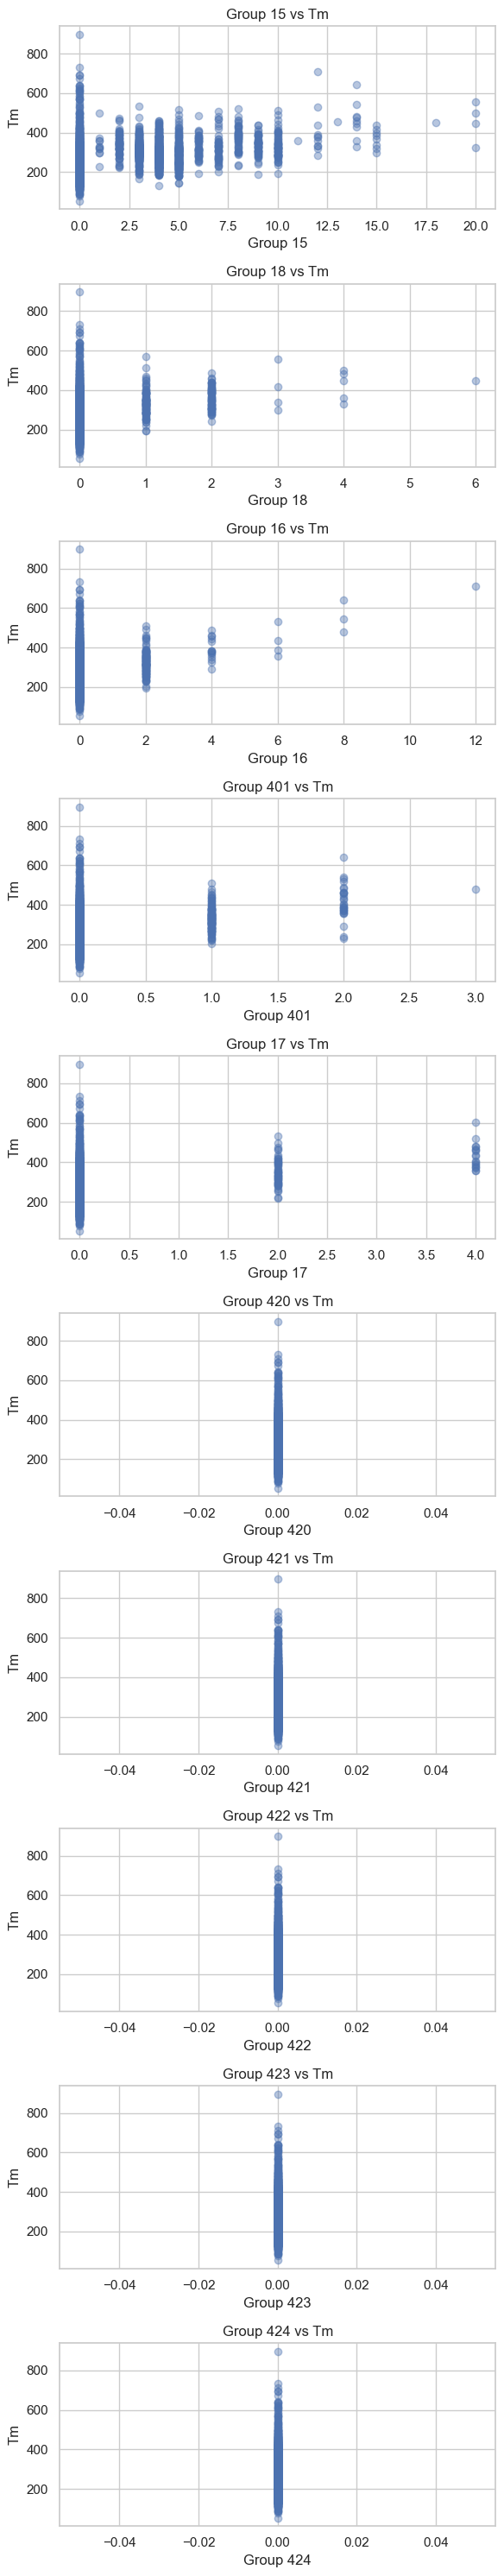

In [13]:
top_pos = corr.head(5).index.tolist()
top_neg = corr.tail(5).index.tolist()
top_features = top_pos + top_neg

fig, axes = plt.subplots(len(top_features), 1, figsize=(6, 3 * len(top_features)))
for ax, col in zip(axes, top_features):
    ax.scatter(train_df[col], train_df[target_col], alpha=0.4)
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
    ax.set_title(f'{col} vs {target_col}')
plt.tight_layout()

## Train/test column alignment

In [14]:
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

print('Only in train:', sorted(list(train_cols - test_cols))[:20])
print('Only in test:', sorted(list(test_cols - train_cols))[:20])

Only in train: ['Tm']
Only in test: []
